# Sprint 16 - Modelamiento con Series Temporales (Sesiones)

En numerosos problemas reales de ciencia de datos, el objetivo no es predecir una variable a partir de un conjunto amplio de atributos independientes, sino estimar su valor futuro utilizando únicamente su propio comportamiento histórico. Este tipo de información se conoce como **Serie temporal**, es decir, una secuencia de observaciones registradas en orden cronológico. 

Las **Series temporales** presentan una característica fundamental que las diferencia de muchos conjuntos de datos tradicionales: las observaciones no necesariamente son independientes entre sí. El valor observado en un momento determinado suele estar relacionado con los valores observados previamente, generando patrones de tendencia, estacionalidad, persistencia y dependencia temporal. Por esta razón, el análisis de series temporales requiere herramientas estadísticas específicas orientadas a estudiar cómo evoluciona la variable a lo largo del tiempo.

En este caso de estudio aprenderemos a analizar una **Serie temporal** y a construir las bases necesarias para generar modelos predictivos sobre ella. Antes de entrenar cualquier algoritmo, resulta indispensable comprender la estructura temporal de los datos, identificando componentes de los mismos y patrones distintivos. Por tanto, trabajaremos tres conceptos fundamentales:

* Descomposición: consiste en separar la serie en componentes interpretables —habitualmente tendencia, estacionalidad y residuo— con el fin de entender qué parte del comportamiento observado corresponde a cambios de largo plazo, qué parte se repite periódicamente y qué parte puede considerarse ruido o variación no explicada por la misma serie.
* Estacionariedad: se refiere a la estabilidad estadística de la serie a lo largo del tiempo. Muchos métodos de modelado temporal funcionan mejor o requieren que ciertas propiedades, como la media y la varianza, permanezcan relativamente constantes. Detectar y tratar series no estacionarias es una etapa clave en el análisis temporal.
* Autocorrelación: mide el grado de relación entre los valores de la serie y sus propios rezagos temporales. Analizar la autocorrelación permite identificar dependencias temporales, ciclos y retardos relevantes que pueden utilizarse para una mejor predicción.

Una vez comprendidos estos conceptos, los aplicaremos para construir atributos derivados de la **Serie temporal**, tales como rezagos, medias móviles, diferencias y componentes temporales. Estos atributos servirán como entradas para algoritmos de aprendizaje supervisado que ya conocemos, permitiéndonos combinar técnicas de análisis temporal con modelos predictivos tradicionales.

De forma adicional, en este proyecto presentaremos un nuevo algoritmo predictivo: el **Bosque Aleatorio para Regresión**. Este método pertenece a la familia de los algoritmos de **ensamblaje** como los GBM, y puede entenderse como una colección de múltiples árboles de decisión que trabajan de manera paralela para resolver un mismo problema predictivo. Cada árbol es entrenado utilizando una muestra ligeramente diferente de los datos disponibles y, en muchos casos, considerando también subconjuntos distintos de atributos. Como resultado, cada árbol genera una predicción propia que luego es combinada con las demás para así obtener una única estimación sobre la variable objetivo.   

Visto esto, el objetivo de este caso no será únicamente aprender a generar pronósticos, sino desarrollar una intuición sólida sobre el comportamiento de las **Series temporales** y comprender por qué el tratamiento estadístico adecuado de la dimensión temporal es tan importante para obtener predicciones confiables y útiles en aplicaciones reales.

## Entendimiento del contexto

En la actualidad, la calidad del aire se ha convertido en uno de los principales desafíos para las ciudades modernas debido a su impacto directo sobre la salud de las personas, el medio ambiente y la calidad de vida en general. El crecimiento urbano, el aumento del parque automotor, las actividades industriales y otros factores asociados al desarrollo económico han contribuido a incrementar la concentración de diversos contaminantes atmosféricos, generando riesgos que afectan especialmente a los grupos más vulnerables de la población.

Consciente de esta problemática, el Municipio de tu ciudad ha fortalecido sus iniciativas de monitoreo ambiental mediante la instalación de sensores que registran de manera continua diferentes indicadores relacionados con la calidad del aire. Entre los contaminantes que más preocupación generan se encuentra el monóxido de carbono (CO), un gas que puede ser emitido por muchas de las fuentes ya mencionadas. Debido a sus efectos potencialmente perjudiciales para la salud humana, resulta fundamental mantener un seguimiento permanente de sus niveles de concentración.

En este contexto, las autoridades municipales han identificado la necesidad de complementar los sistemas de monitoreo existentes con herramientas predictivas que permitan anticipar posibles episodios de deterioro de la calidad del aire. Contar con estimaciones confiables sobre la concentración futura de contaminantes facilitaría una gestión más proactiva de los riesgos ambientales, permitiendo actuar antes de que se produzcan condiciones desfavorables para la población.

Por esta razón, has sido contratado como científico de datos para desarrollar un modelo capaz de predecir la concentración de monóxido de carbono para el día siguiente a la realización del pronóstico, utilizando la información histórica registrada por los sensores instalados en la ciudad. El desafío consiste en analizar el comportamiento temporal de este contaminante, identificar patrones relevantes y construir una herramienta que proporcione pronósticos útiles para la toma de decisiones.

Los resultados obtenidos tendrán aplicaciones prácticas importantes. Por una parte, permitirán emitir alertas y boletines preventivos dirigidos a la ciudadanía cuando se anticipen niveles elevados de contaminación. Por otra, proporcionarán información valiosa para el diseño de políticas públicas y ordenanzas orientadas a reducir las emisiones contaminantes y mejorar la sostenibilidad ambiental de la ciudad. De esta manera, el proyecto contribuirá tanto a la protección de la salud pública como al desarrollo de una ciudad más resiliente y amigable con el medio ambiente.

## Entendimiento de los datos

Carga las librerías y funciones con las que trabajarás en este caso, y entre las que debes incluir `LinearRegression`, `train_test_split`, `metrics`, así como `RandomForestRegressor` del módulo `ensemble`. Adicionalmente, de la librería **statsmodels** importa lo siguiente:

* `seasonal_decompose` del módulo `tsa.seasonal`.
* `pacf` y `adfuller` del módulo `tsa.stattools`.

Igualmente importa la librería **datetime** ya que nos ayudará a procesar fácilmente las dimensiones temporales de nuestros datos. 

In [1]:
# Cargar librerías para manipulacion y visualizacion de datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt

# Cargar librerias para modelamiento
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics
from sklearn.model_selection import train_test_split
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import pacf, adfuller

La entidad ha compartido contigo el archivo [**emisiones_co.csv**](https://raw.githubusercontent.com/jsaraujo5081/material_curso_data_science/refs/heads/main/datasets/emisiones_co.csv) para que lo cargues a continuación.

In [2]:
# Cargar datos
df_emisiones = pd.read_csv("https://raw.githubusercontent.com/jsaraujo5081/material_curso_data_science/refs/heads/main/datasets/emisiones_co.csv")

# Mostrar estructura de datos
df_emisiones.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50142 entries, 0 to 50141
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   fecha         50142 non-null  int64  
 1   hora          50142 non-null  int64  
 2   emisiones_co  50142 non-null  float64
dtypes: float64(1), int64(2)
memory usage: 1.1 MB


Este dataset contiene más de 50,000 registros históricos levantados durante los últimos 6 años por los mencionados sensores de emisiones. Las columnas de esta tabla se describen a continuación:

* fecha: Fecha en la que se registró una medición de CO a partir del 1 de enero de 2019.
* hora: Hora en la que se registró una medición de CO.
* emisiones_co: Nivel de concentración de emisiones de CO en $mg/m^3$.

Explora el dataset para que a partir de aquí definas un objetivo técnico, los algoritmos y métricas a utilizar, y un plan de acción para el procesamiento e ingeniería de datos.

In [3]:
# Generar una muestra de los datos
df_emisiones.sample(10)

,fecha,hora,emisiones_co
39057,45175,12,0.023
15539,44155,13,0.854
30115,44785,19,0.889
37900,45125,4,0.351
31147,44830,19,0.685
19472,44324,15,0.296
48215,45554,12,0.491
16964,44216,19,0.802
16642,44202,23,0.387
6461,43754,6,0.640


In [4]:
# Mostrar resumen estadístico de variables
df_emisiones.describe().round(2)

,fecha,hora,emisiones_co
count,50142.00,50142.00,50142.00
mean,44564.55,11.71,0.64
std,628.86,6.86,0.37
min,43466.00,0.00,-0.71
25%,44025.00,6.00,0.40
50%,44567.00,12.00,0.56
75%,45112.00,18.00,0.79
max,45626.00,23.00,3.87


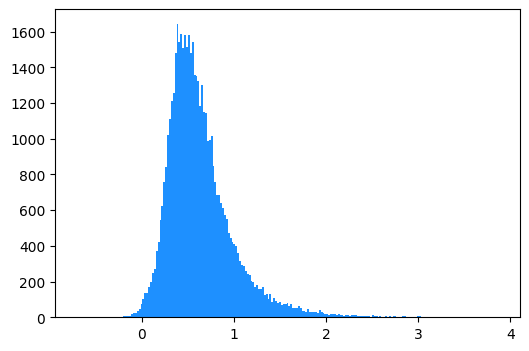

In [5]:
# Visualizar distribucion de emisiones
df_emisiones.plot(
    kind = "hist",
    bins = int(np.sqrt(df_emisiones.shape[0])),
    y = "emisiones_co",
    legend = False,
    figsize = [6,4],
    ylabel = "",
    color = "dodgerblue" 
)
plt.show()

In [6]:
# Verificar cantidad de registros con emisiones negativas
print(df_emisiones.query("emisiones_co < 0")["emisiones_co"].count())

230


In [7]:
# Verificar cantidad de registros de emisiones excesivamente altos (atípicos)
umbral = df_emisiones["emisiones_co"].quantile(0.99)
print(df_emisiones.query("emisiones_co > @umbral")["emisiones_co"].count())

502


**OBJETIVO TÉCNICO**

Pronosticar con alta asertividad la variable objetivo emisiones_co generando para esto atributos a partir del análisis de series temporales. Por lo expuesto, se debe crear un modelo supervisado de regresión que permita predecir la cantidad de emisiones de CO (monóxido de carbono) que existirán al día siguiente en la ciudad.

**ALGORITMO Y MÉTRICAS DE RENDIMIENTO**

* Algoritmos: **Regresión lineal**, **Regresión con Bosque aleatorio**.
* Métricas de rendimiento: **Coeficiente de determinación (R2)**.

**PLAN DE ACCION PARA PREPARACIÓN E INGENIERÍA DE DATOS**

| # | Acción de preparación |
| ---- | ---- |
| 1 | Convertir el tipo de la columna fecha para facilitar a partir de aquí el análisis de series temporales. Vale considerar que de momento estas fechas están siendo presentadas como una secuencia numérica donde el valor 43466 (minimo) corresponde a 2019-01-01. |
| 2 | Eliminar casos atípicos detectados y que corresponden a valores negativos o excesivamente altos. Esto permitirá además contar con una variable objetivo que siga una distribución aproximadamente normal. |
| 3 | Agrupar los datos para presentarlos como promedios diarios. Lo anterior, debido a que este es el nivel temporal requerido para el desarrollo del modelo predictivo. |

<br />

| # | Acción de ingeniería |
| ---- | ---- |
| 1 | Crear atributos a partir de un análisis estadístico de series temporales a realizar previamente. |
| 2 | Separar el dataset en atributos y variable objetivo. |
| 3 | Escalar la variable objetivo para asegurar que la misma siga una distribución aproximadamente normal visto que se utilizará un algoritmo de regresión lineal. |
| 4 | Particionar el dataset en conjuntos de prueba y entrenamiento. Considerar en cuanto a esto la particularidad que se está trabajando con series temporales. | 

## Preparación de datos

Limpia los datos conforme el plan de acción definido.

In [8]:
# Cambiar el tipo de la fecha
fecha_base = dt.date(2019,1,1)
ref_min = int(df_emisiones["fecha"].min())
df_emisiones["fecha"] = df_emisiones["fecha"].apply(lambda x: fecha_base + dt.timedelta(x - ref_min))
df_emisiones["fecha"] = pd.to_datetime(df_emisiones["fecha"])
df_emisiones["fecha"].describe().loc[["min","max"]]

min    2019-01-01 00:00:00
max    2024-11-30 00:00:00
Name: fecha, dtype: object

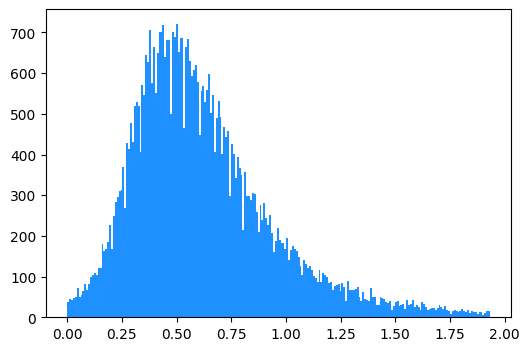

In [9]:
# Quitar valores extraños detectados 
df_emisiones = df_emisiones.query("emisiones_co >= 0").query("emisiones_co <= @umbral")
df_emisiones.plot(
    kind = "hist",
    bins = int(np.sqrt(df_emisiones.shape[0])),
    y = "emisiones_co",
    legend = False,
    figsize = [6,4],
    ylabel = "",
    color = "dodgerblue" 
)
plt.show()

In [10]:
# Agrupar datos por dia
df_emisiones_d = (
    df_emisiones
    .groupby("fecha")
    .agg(emisiones = ("emisiones_co","median"))
    .sort_index()
)
df_emisiones_d.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2147 entries, 2019-01-01 to 2024-11-30
Data columns (total 1 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   emisiones  2147 non-null   float64
dtypes: float64(1)
memory usage: 33.5 KB


## Análisis exploratorio de series temporales

Antes de iniciar con la construcción de un modelo predictivo para nuestro caso, conviene conocer las características distintivas de la **Serie temporal** en cuestión. En concreto, nos interesa dar respuesta a las siguientes preguntas:

* ¿Cómo es el comportamiento general de las emisiones a través del tiempo?
* ¿Este comportamiento puede ser descrito como una función del tiempo?
* ¿El comportamiento futuro de las emisiones puede describirse como una función de su comportamiento pasado?

Dar solución a estas interrogantes es importante pues adicional a ayudarnos a comprender de mejor forma a nuestra variable objetivo, nos permitirá crear los atributos necesarios para alimentar y entrenar el algoritmo de nuestro modelo.

Por tanto, en primer lugar conviene que visualices la serie temporal para comprender de mejor forma su evolución a través del tiempo.

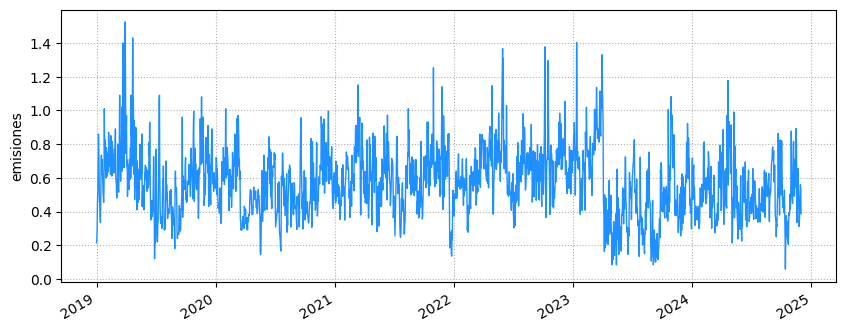

In [11]:
df_emisiones_d.plot(
    figsize = [10,4],
    linewidth = 1,
    color = "dodgerblue",
    legend = False,
    xlabel = "",
    ylabel = "emisiones"
)
plt.grid(linestyle = ":")
plt.show()

Como puedes evidenciar en el gráfico anterior, describir el comportamiento de esta serie temporal puede ser complejo dados los continuos cambios a través del tiempo. Entonces, podría ser conveniente quizás enfocarnos en cada año para reducir la magnitud del problema. Visualiza la evolución de las emisiones en separado por todos los años existentes en la serie.

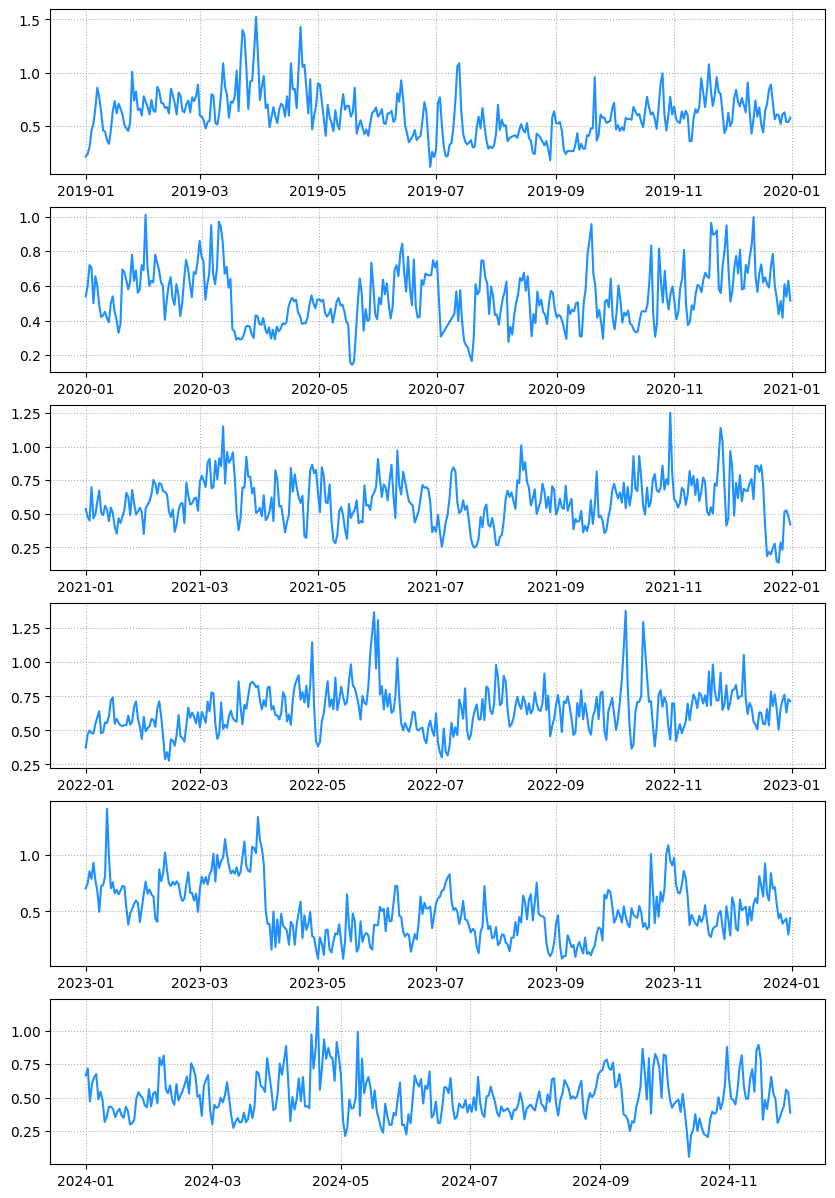

In [12]:
periodos = df_emisiones_d.index.year.unique()
fig, ax = plt.subplots(nrows = 6, figsize = [10,15])
for p in periodos:
    df_periodo = df_emisiones_d[df_emisiones_d.index.year == p]
    ax[p - 2019].plot(
        df_periodo["emisiones"],
        color = "dodgerblue"
    )
    ax[p - periodos.min()].grid(linestyle = ":")
plt.show()

Un poco mejor, aunque aún es difícil encontrar patrones más generales del comportamiento de emisiones. Probemos ahora agregando temporalmente la serie para ver si se aprecia algo más. Visualiza la variable con una granularidad mensual (y ya no diaria). Aplica para esto el método `resample` de **Pandas** con el argumento `dt.timedelta(30)`, y calcula su promedio. 

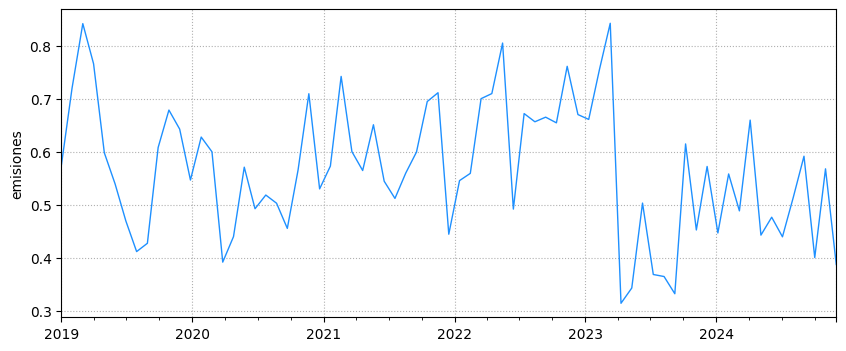

In [13]:
(
    df_emisiones_d
    .resample(dt.timedelta(30))
    .mean()
    .plot(
        figsize = [10,4],
        legend = False,
        linewidth = 1,
        color = "dodgerblue",
        xlabel = "",
        ylabel = "emisiones"
    )
)
plt.grid(linestyle = ":")
plt.show()

Hemos reducido la complejidad significativamente y ya podemos observar algunos comportamientos de mejor manera aunque los mismos no terminan siendo suficientemente claros. Intenta un mejor resultado con una agregación anual.

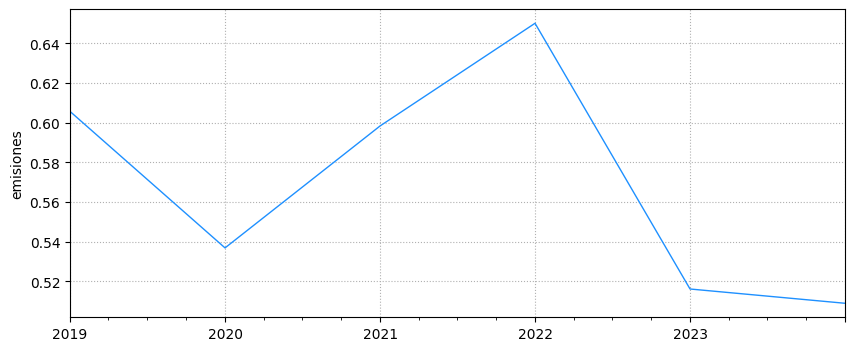

In [14]:
(
    df_emisiones_d
    .resample(dt.timedelta(365))
    .mean()
    .plot(
        figsize = [10,4],
        legend = False,
        linewidth = 1,
        color = "dodgerblue",
        xlabel = "",
        ylabel = "emisiones"
    )
)
plt.grid(linestyle = ":")
plt.show()

Ya se cuenta con una visión clara del comportamiento de largo plazo de nuesta serie aunque esto ha repercutido potencialmente en la pérdida de información relevante. Probemos entonces una mejor estrategia que simplifique la comprensioó del comportamiento de la serie, pero que no implique sacrificar sus detalles específico. 

### Descomposición de series temporales

Las técnicas de visualización antes expuestas facilitan la comprensión del comportamiento de largo plazo de una **Serie temporal**, sin embargo no son suficientes para tener una perspectiva objetiva y completa de tendencias o estacionalidades de la misma. Es por esta razón que existe el método de **descomposión** y lo explicaremos a continuación. Por definición, toda **Serie temporal** puede descomponerse en los siguientes factores:

* El primero de ellos se denomina tendencia ($\tau$) y hace referencia al comportamiento de mediano/largo plazo de la serie.
* El siguiente es la estacionalidad ($\sigma$) que explica las fluctuaciones cíclicas en el corto plazo.
* Finalmente, queda el componente aleatorio o residuo ($\rho$), que comprende todas aquellas variaciones aleatorias o cuya explicación va más allá de los datos disponibles.

Es así que dada una serie temporal $y_t$, con $t \in T \subset \mathbb N$ como un índice que representa el tiempo, se cumple que

$$ y_i = \tau_i \times \sigma_i \times \rho_i\quad \forall i \in T $$

Regresemos a nuestras emisiones diarias y empieza obteniendo el componente de tendencia mediante el método `rolling` seguido del método `mean`. Guarda el resultado como una nueva columna del dataset, aunque conviene que trabajes con una copia de nuestra serie original para no alterar los datos fuente. Visto que la agregación ha mostrado una mejor interpretabilidad a nivel anual, utiliza el argumento `window = 365`.

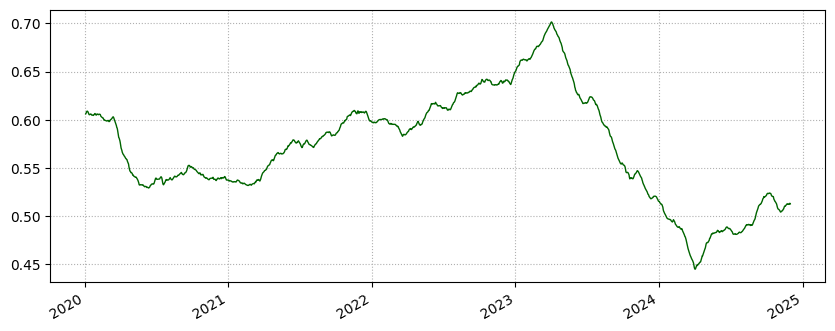

In [15]:
# Calcular tendencia
df_copia = df_emisiones_d.copy()
df_copia["tendencia"] = (
    df_copia["emisiones"]
    .rolling(window = 365)
    .mean()
)

# Visualizar tendencia
df_copia.plot(
    y = "tendencia",
    figsize = [10,4],
    linewidth = 1,
    legend = False,
    xlabel = "",
    color = "darkgreen"
)
plt.grid(linestyle = ":")
plt.show()

Lo que aquí has obtenido es también conocido como **media móvil** y en este caso no es más que un promedio de las 365 observaciones precedentes para cada registro de la serie de tiempo. Es decir, la media móvil $\bar y_i$ en el momento $i\in T$ se define por

$$ \bar y_i = \frac{1}{365}\sum_{k = 0}^{364} y_{i-k} $$

Notemos que la tendencia obtenida ya nos permite generar las mismas conclusiones que cuando agregamos de forma temporal los datos, puesto que evidencia el comportamiento de largo plazo de la serie. En concreto, se puede observar que:

* El inicio de la pandemia del COVID generó una reducción de las emisiones en la ciudad, visto que hubo una cuarentena forzosa y por ende una reducción significativa de las fuentes de contaminación en la ciudad.
* Existe una tendencia de crecimiento constante hasta inicios de 2023 producto de la flexibilización de las medidas preventivas por la pandemia y la reactivación económica.
* Hay una reducción importante a partir del sengundo trimestre de 2023, y luego de esto un comportamiento estable. Se puede presumir que luego de la pandemia, se implementaron medidas de control por parte del municipio de la ciudad para controlar el incremento precedente.

Aún podemos seguir estudiando en un detalle mas granular esta serie. Pasemos ahora a la estacionalidad $\sigma$. Obtenla siguiendo estos pasos:

1. En el dataset copiado que ya tienes, crea una columna donde dividas la serie original por la tendencia, y llámala "resto". 
2. Extrae el dia del año de la fecha y guárdalo en la columna "dia".
3. Agrupa los datos por día y calcula la mediana de resto. Guarda este resultado en `df_est`.
4. Une `df_est` con el dataset copia utilizando como clave de union la columna dia.
5. Elimina del dataset las columnas auxiliar dia.

In [16]:
# Crear columna resto
df_copia["resto"] = df_copia["emisiones"] / df_copia["tendencia"]

# Crear columna dia
df_copia["dia"] = df_copia.index.dayofyear

# Agrupar datos por dia y calcular promedio de resto
df_est = (
    df_copia
    .groupby("dia")
    .agg(estacionalidad = ("resto","median"))
)

# Unir estacionalidad con la serie original
df_copia = df_copia.merge(
    df_est,
    on = "dia"
)
df_copia.index = df_emisiones_d.index

# Eliminar columnas auxiliares
df_copia = df_copia.drop(columns = "dia")
df_copia.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2147 entries, 2019-01-01 to 2024-11-30
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   emisiones       2147 non-null   float64
 1   tendencia       1783 non-null   float64
 2   resto           1783 non-null   float64
 3   estacionalidad  2147 non-null   float64
dtypes: float64(4)
memory usage: 83.9 KB


Visualiza ahora esta estacionalidad.

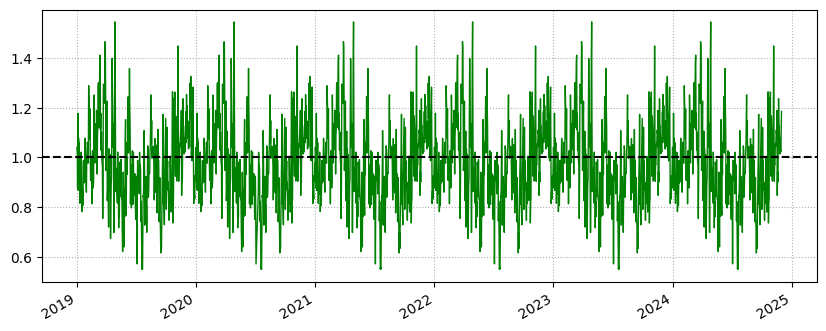

In [17]:
df_copia.plot(
    y = "estacionalidad",
    figsize = [10,4],
    linewidth = 1,
    legend = False,
    xlabel = "",
    color = "green"
)
plt.axhline(y = 1, color = "black", linestyle = "--")
#plt.xticks(range(0,365,30))
plt.grid(linestyle = ":")
plt.show()

Con este gráfico ya se puede afirmar lo siguiente respecto a comportamientos de corto plazo y que resulta consistente considerando las épocas de verano e invierno del año: 

* Existe una "temporada baja" de emisiones entre junio a octubre aproximadamente (mediados de cada año).
* Por su parte la "temporada alta" se ubica entre febrero a abril, y noviembre a diciembre (principios y finales de cada año). 

Obtén finalmente el componente residual $\rho$ dividiendo la columna resto por la estacionalidad, y visualízalo. Puedes tambien ya eliminar esta columna auxiliar resto.

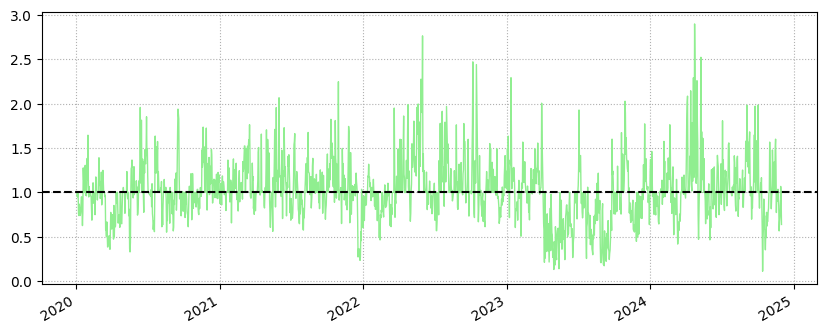

In [18]:
# Calcular columna residuo
df_copia["residuo"] = df_copia["resto"] / df_copia["estacionalidad"]
df_copia = df_copia.drop(columns = "resto")

#Visualizar columna residuo
df_copia.plot(
    y = "residuo",
    figsize = [10,4],
    linewidth = 1,
    legend = False,
    xlabel = "",
    color = "lightgreen"
)
plt.axhline(y = 1, color = "black", linestyle = "--")
plt.grid(linestyle = ":")
plt.show()

Como mencionamos, en el componente residual se explican todos aquellos factores externos y no observados que inciden en las emisiones en un momento del tiempo dado.

Toda esta descomposición puede hacerse automáticamente con la función `seasonal_decompose`. Pruébala y evidencia que obtienes resultados bastante similares a los alcanzados en los puntos anteriores. Utiliza los argumentos `period = 365`, `model = "multiplicative"` y `two_seded = False`

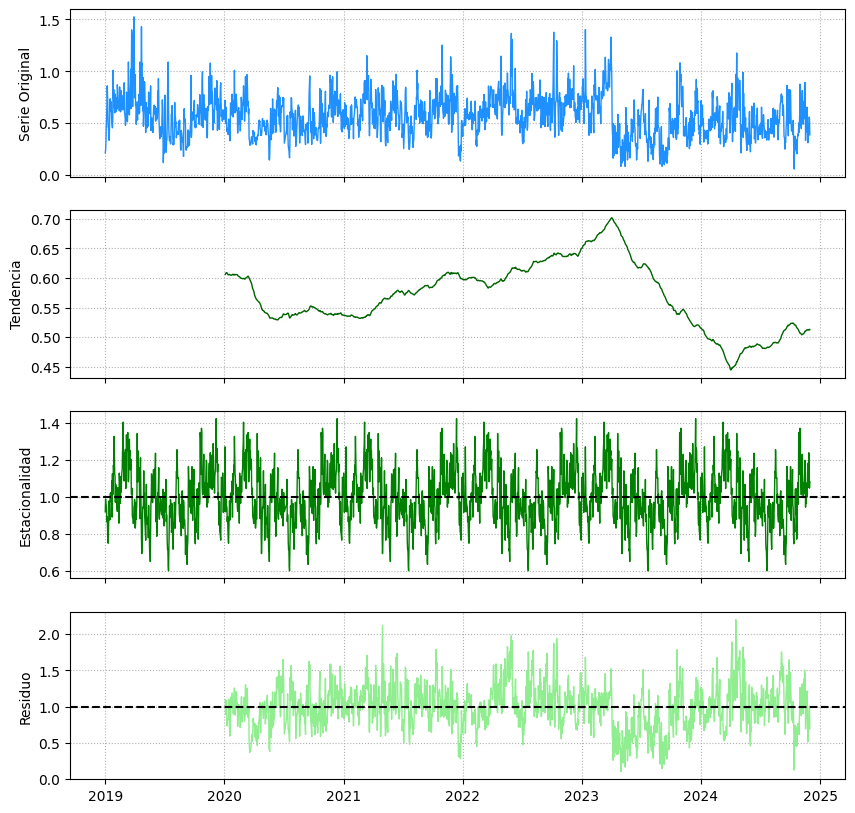

In [19]:
# Descomponer la serie con funcion seasonal_decompose
descomp = seasonal_decompose(
    df_emisiones_d,
    period = 365,
    model = "multiplicative",
    two_sided = False
)

# Visualizar componentes extraidos
fig, ax = plt.subplots(nrows = 4, figsize = [10,10], sharex = True)
ax[0].plot(
    df_emisiones_d["emisiones"],
    linewidth = 1,
    color = "dodgerblue"
)
ax[0].set_ylabel("Serie Original")
ax[0].grid(linestyle = ":")
ax[1].plot(
    descomp.trend,
    linewidth = 1,
    color = "darkgreen"
)
ax[1].set_ylabel("Tendencia")
ax[1].grid(linestyle = ":")       
ax[2].plot(
    descomp.seasonal,
    linewidth = 1,
    color = "green"
)
ax[2].set_ylabel("Estacionalidad")
ax[2].axhline(y = 1, color = "black", linestyle = "--")     
ax[2].grid(linestyle = ":")
ax[3].plot(
    descomp.resid,
    linewidth = 1,
    color = "lightgreen"
)
ax[3].set_ylabel("Residuo")
ax[3].axhline(y = 1, color = "black", linestyle = "--")     
ax[3].grid(linestyle = ":") 
plt.show()

### Estacionareidad en series temporales

Una característica muy importante a nivel de series temporales hace referencia a la **estacionareidad**. Una serie es estacionaria si su valor promedio y su variabilidad son INDEPENDIENTES del tiempo. Cuando existe **estacionareidad**, resulta más sencillo modelar las relaciones temporales presentes en los datos, ya que estas tienden a mantenerse estables en el tiempo; por esta razón, muchos métodos de pronóstico requieren o se benefician de series estacionarias.

Intenta entonces verificar visualmente si existe alguna relación entre el promedio y el tiempo dada nuestra serie temporal de emisiones. Utiliza el concepto de media móvil al igual que antes.

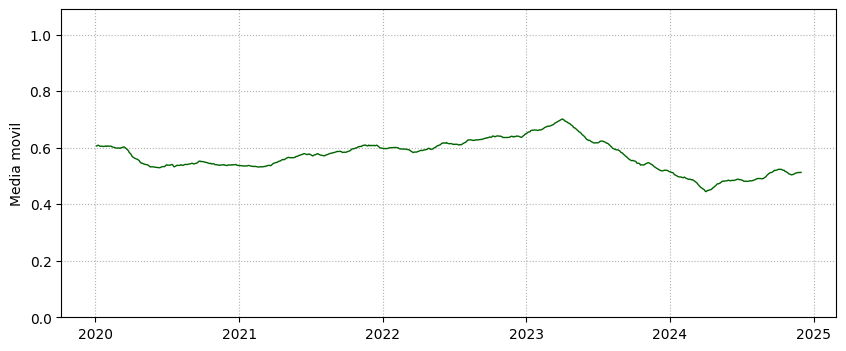

In [20]:
# Calcular media movil
media_movil = (
    df_emisiones_d
    .rolling(365)
    .mean()
)

# Visualizar media móvil
plt.figure(figsize = [10,4])
plt.plot(
    media_movil,
    linewidth = 1,
    color = "darkgreen"
)
plt.ylabel("Media movil")
plt.ylim([0,df_emisiones_d["emisiones"].quantile(0.99)])
plt.grid(linestyle = ":")
plt.show()

Del gráfico anterior se desprende que no parece existir ninguna función conocida que describa este comportamiento a nivel del promedio de la serie. 

Has lo mismo pero ahora con la varianza.

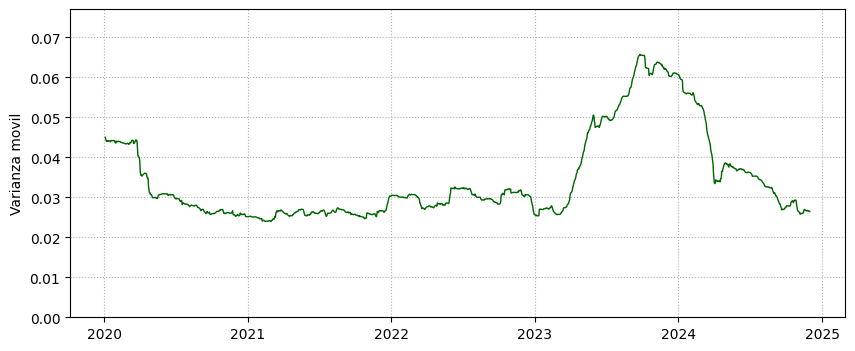

In [21]:
# Calcular varianza movil
var_movil = (
    df_emisiones_d
    .rolling(365)
    .var()
)

# Visualizar varianza móvil
plt.figure(figsize = [10,4])
plt.plot(
    var_movil,
    linewidth = 1,
    color = "darkgreen"
)
plt.ylabel("Varianza movil")
plt.ylim([0,df_emisiones_d["emisiones"].var() * 2])
plt.grid(linestyle = ":")
plt.show()

A pesar del incremento en la variabilidad del 2023, o parece haber alguna relación funcional clara entre el tiempo y la variabilidad de las emisiones. Por tanto, existe evidencia a favor de la **estacionareidad** de la serie.

Estos resultados en todo caso no son concluyentes pues solamente surgen de un estudio visual, y podríamos estar alcanzando una interpretación errónea. Justamente por esta razón es que se ha desarrollado la prueba **Dickey-Fuller** que evalúa las siguientes hipótesis:

| Hipótesis | Postulado |
| ---- | ---- |
| Nula | La serie temporal NO es estacionaria. |
| Alternativa | La serie temporal SÍ es estacionaria. |

Lleva a cabo esta prueba de hipótesis mediante la función `adfuller`, de donde puedes extraer el valor p correspondiente indexando por el elemento de posición 1, y utiliza una significancia del 5%.

In [22]:
# Ejecutar test Dickey-Fuller
p_value = adfuller(df_emisiones_d)[1]

# Constrastar valor p con significancia
print(f"El valor p es: {p_value:.2%}")
if p_value > 0.05:
    print("Serie temporal NO es estacionaria")
else:
    print("Serie temporal SI es estacionaria")

El valor p es: 0.00%
Serie temporal SI es estacionaria


Queda confirmada estadísticamente nuestra suposición a partir de las visualizaciones, ¿pero qué sucede si no se evidencia estacionareidad en los datos? Tomemos un ejemplo muy básico que nos permita presentar el método de **integración** de series. Crea una serie de 100 observaciones que estén definidos en el tiempo de acuerdo a la función $f(i) = (i + \epsilon)^2$ de acuerdo al siguiente código:

```py
np.random.seed(123)
serie_ejemplo = pd.DataFrame(dict(
    datos = [(x + 10*np.random.randn())**2 for x in range(100)] 
))
```

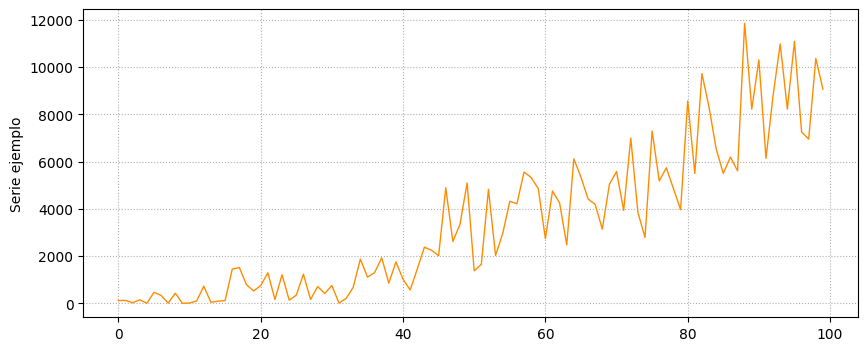

In [23]:
# Generar serie de ejemplo
np.random.seed(123)
serie_ejemplo = pd.DataFrame(dict(
    datos = [(x + 10*np.random.randn())**2 for x in range(100)] 
))

# Visualizar serie de ejemplo
plt.figure(figsize = [10,4])
plt.plot(
    serie_ejemplo,
    linewidth = 1,
    color = "darkorange"
)
plt.ylabel("Serie ejemplo")
plt.grid(linestyle = ":")
plt.show()

Visualiza la evolución del promedio y la variabilidad de esta serie.

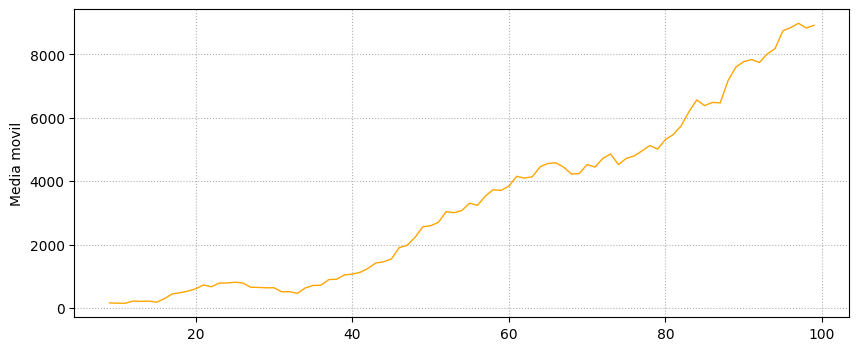

In [24]:
# Visualizar promedio
plt.figure(figsize = [10,4])
plt.plot(
    serie_ejemplo.rolling(10).mean(),
    linewidth = 1,
    color = "orange"
)
plt.ylabel("Media movil")
plt.grid(linestyle = ":")
plt.show()

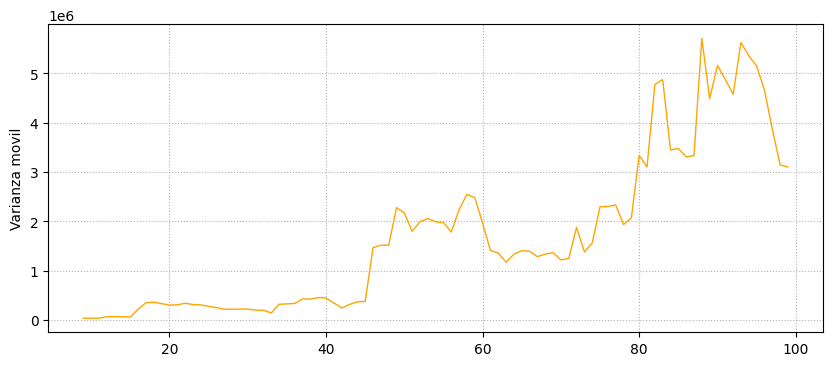

In [25]:
# Visualizar varianza
plt.figure(figsize = [10,4])
plt.plot(
    serie_ejemplo.rolling(10).var(),
    linewidth = 1,
    color = "orange"
)
plt.ylabel("Varianza movil")
plt.grid(linestyle = ":")
plt.show()

Visualmente parece que no existe **estacionareidad** ya que a medida que pasa el tiempo el promedio y la variabilidad aumentan. Ratifica esto ejecutando la prueba Dickey - Fuller sobre la serie.

In [26]:
# Ejecutar test Dickey-Fuller y extraer valor p
p_value = adfuller(serie_ejemplo)[1]

# Constrastar valor p con significancia
print(f"El valor p es: {p_value:.2%}")
if p_value > 0.05:
    print("Serie temporal NO es estacionaria")
else:
    print("Serie temporal SI es estacionaria")

El valor p es: 99.74%
Serie temporal NO es estacionaria


Dado que esta serie NO es estacionaria, podemos transformarla mediante la operación llamada **integración de series**. Este método establece que si $y_t$ es una serie no estacionaria, entonces la serie de diferencias $z_t = y_t - y_{t-1}$ tendrá mayor probabilidad de serlo. Integra entonces la serie de ejemplo y verifica si la misma es estacionaria. Si estimas pertinente, utiliza el método `shift` con el argumento `periods = 1` para desplazar la serie una unidad.

In [27]:
# Integrar serie
serie_integrada = serie_ejemplo - serie_ejemplo.shift(periods = 1)
serie_integrada = serie_integrada.dropna()

# Ejecutar test Dickey-Fuller
p_value = adfuller(serie_integrada)[1]

# Constrastar valor p con significancia
print(f"El valor p es: {p_value:.2%}")
if p_value > 0.05:
    print("Serie temporal NO es estacionaria")
else:
    print("Serie temporal SI es estacionaria")

El valor p es: 10.94%
Serie temporal NO es estacionaria


Fíjate que el valor p obtenido se ha reducido, lo cual es evidencia que la **integración** ayuda a generar **estacionareidad**. Este proceso puede repetirse las veces que sean necesarias hasta alcanzar la estacionareidad deseada. Haslo una vez más para ver qué sucede.

In [28]:
# Integrar serie
serie_integrada2 = serie_integrada - serie_integrada.shift(periods = 1)
serie_integrada2 = serie_integrada2.dropna()

# Ejecutar test Dickey-Fuller
p_value = adfuller(serie_integrada2)[1]

# Constrastar valor p con significancia
print(f"El valor p es: {p_value:.2%}")
if p_value > 0.05:
    print("Serie temporal NO es estacionaria")
else:
    print("Serie temporal SI es estacionaria")

El valor p es: 0.00%
Serie temporal SI es estacionaria


Visualiza esta serie doblemente integrada.

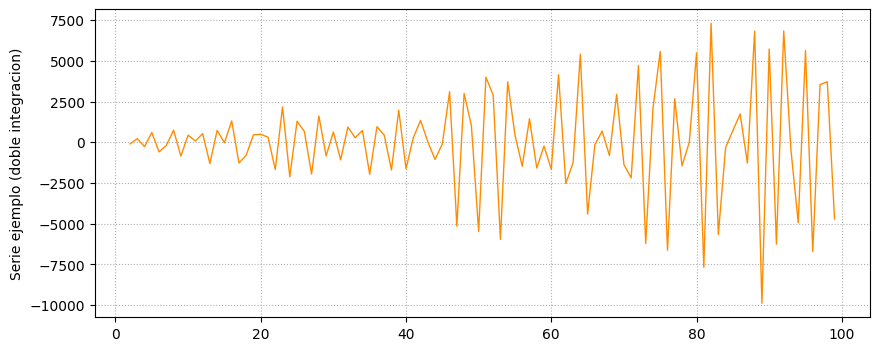

In [29]:
plt.figure(figsize = [10,4])
plt.plot(
    serie_integrada2,
    linewidth = 1,
    color = "darkorange"
)
plt.ylabel("Serie ejemplo (doble integracion)")
plt.grid(linestyle = ":")
plt.show()

### Autocorrelación

La **autocorrelación** es una característica que hace referencia a la capacidad que tiene una observación pasada en la serie de pronosticar un valor futuro. En concreto, sea nuestra serie $y_t$, que tiene dos observaciones $y_i$ y $y_{i-k}$ donde $k > 0$ se denomina **lag**. Entonces, la **autocorrelación** corresponde a la magnitud en que $y_{i-k}$ puede explicar por sí misma el valor de $y_i$. En otras palabras, si existe autocorrelación entre una serie y uno de sus lags, el segundo podría utilizarse como atributo predictor en un modelo predictivo.

Visto esto, estudia la **autocorrelación** de nuestra serie de emisiones diarias mediante la función `pacf` con 60 lags.

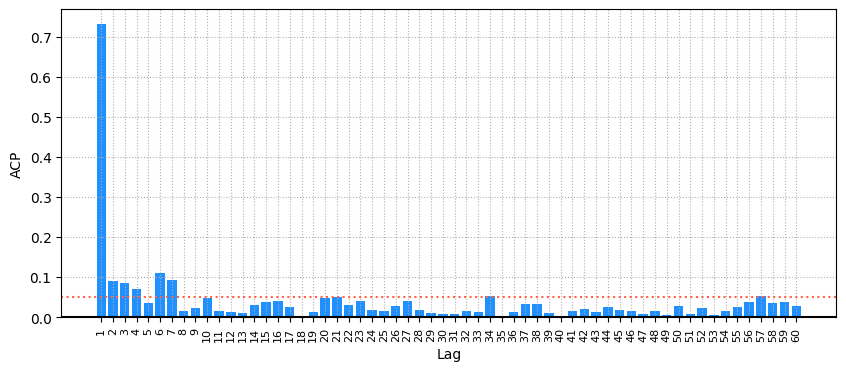

In [30]:
#Estimar la autocorrelación parcial entre lags
autocorr = pacf(
    df_emisiones_d, 
    nlags = 60
)

#Visualizar autocorrelación
plt.figure(figsize = [10,4])
plt.bar(
    x = range(1,61),
    height = abs(autocorr[1:]),
    color = "dodgerblue"
)
plt.xticks(range(1,61), size = 8, rotation = 90)
plt.grid(linestyle = ":")
plt.axhline(y = 0, color = "black")
plt.axhline(y = 0.05, color = "tomato", linestyle = ":")
plt.xlabel("Lag")
plt.ylabel("ACP")
plt.show()

De estos resultados se concluye que las emisiones de hasta una semana previa ($lag \leq 7$) tiene capacidad de pronosticar el valor de la serie ya que su **autocorrelación** es relativamente mayor a otros casos.

## Ingeniería de datos

Del análisis realizado se desprenden los siguientes atributos pontenciales a considerar en nuestro modelo predictivo:

* La tendencia y estacionalidad de la serie.
* Los lags de hasta 7 días previos, dado que existiría autocorrelación.

Créalos como columnas en el dataset de emisiones diarias.

In [31]:
# Descomponer serie 
descomp = seasonal_decompose(
    df_emisiones_d, 
    model = "multiplicative",
    period = 365,
    two_sided = False
)

# Incorporar tendencia
df_emisiones_d["tendencia"] = descomp.trend

# Incorporar estacionalidad
df_emisiones_d["estacionalidad"] = descomp.seasonal

# Incorporar lags de 7 dias previos
for l in range(7):
    df_emisiones_d["lag_{}".format(l+1)] = df_emisiones_d["emisiones"].shift(l + 1)
df_emisiones_d.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2147 entries, 2019-01-01 to 2024-11-30
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   emisiones       2147 non-null   float64
 1   tendencia       1783 non-null   float64
 2   estacionalidad  2147 non-null   float64
 3   lag_1           2146 non-null   float64
 4   lag_2           2145 non-null   float64
 5   lag_3           2144 non-null   float64
 6   lag_4           2143 non-null   float64
 7   lag_5           2142 non-null   float64
 8   lag_6           2141 non-null   float64
 9   lag_7           2140 non-null   float64
dtypes: float64(10)
memory usage: 184.5 KB


Dado esto, podemos afirmar que nuestro modelo sera de tipo **ARIMA(7,0,1)**. Esta notación es frecuentemente usada modelamientos con **Series temporales** y hace referencia a que tiene una autorecursividad (AR) de 7 días, posee 0 integraciones (I), y utiliza una media movil (MA). 

Ahora bien, notemos dos cosas importantes antes de continuar:

* La tendencia y la estacionalidad presentan un potencial error puesto que no hace sentido que el valor de un atributo dependa del valor específico de la variable objetivo. Por tanto, para corregir esta inconsistencia debemos desplazar nuestros atributos con el método `shift`. De esta manera, cada observación ingresada al algoritmo del modelo tendrá como insumo información del día anterior y no del día que se busca pronosticar.
* Existen muchos valores perdidos en los atributos creados. No hace falta darles ningún tratamiento sino que preferentemente vamos a eliminarlos gracias a que tenemos suficientes registros en nuestro dataset.

Ejecuta todas estas acciones de manera ordenada.

In [32]:
# Desplazar tendencia y estacionalidad
df_emisiones_d["tendencia"] = df_emisiones_d["tendencia"].shift(periods = 1)
df_emisiones_d["estacionalidad"] = df_emisiones_d["estacionalidad"].shift(periods = 1)

# Quitar valores perdidos
df_emisiones_d = df_emisiones_d.dropna()
df_emisiones_d.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1782 entries, 2020-01-05 to 2024-11-30
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   emisiones       1782 non-null   float64
 1   tendencia       1782 non-null   float64
 2   estacionalidad  1782 non-null   float64
 3   lag_1           1782 non-null   float64
 4   lag_2           1782 non-null   float64
 5   lag_3           1782 non-null   float64
 6   lag_4           1782 non-null   float64
 7   lag_5           1782 non-null   float64
 8   lag_6           1782 non-null   float64
 9   lag_7           1782 non-null   float64
dtypes: float64(10)
memory usage: 153.1 KB


Continua con la ingeniería separando el dataset en atributos y objetivo; reescalando la variable objetivo para que la misma siga una distribución aproximadamente normal; y posteriormente particionando los datos en conjuntos de entrenamiento y prueba. Para lo último considera que en series temporales es conveniente respetar el orden temporal de la información por lo que utiliza el argumento `shuffle = False`.

In [33]:
# Separar atributos y objetivo
X = df_emisiones_d.drop(columns = "emisiones")
y = df_emisiones_d["emisiones"]

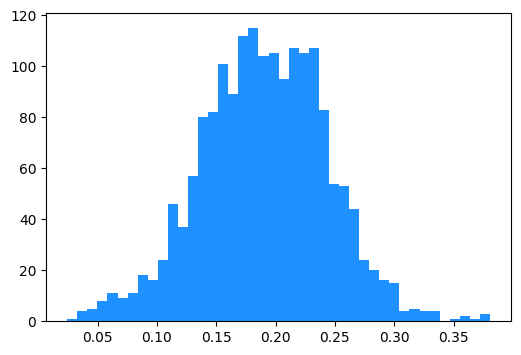

In [34]:
# Reescalar variable objetivo a fin que siga una distribución aproximadamente normal
y = np.log10(y + 1)
plt.figure(figsize = [6,4])
plt.hist(
    y, 
    bins = int(np.sqrt(len(y))),
    color = "dodgerblue"
)
plt.show()

In [35]:
# Particionar datos respetando orden temporal
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    shuffle = False, 
    test_size = 0.3
)
print(X_train.shape)
print(X_test.shape)

(1247, 9)
(535, 9)


## Creación de modelos base

Crea y entrena un modelo base mediante el algoritmo de **regresión lineal** sin intercepto.

In [36]:
# Crear modelo
mod_reg = LinearRegression(fit_intercept = False)

# Entrenar modelo
mod_reg.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",False
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Evalúa el rendimiento del modelo base creado guardando las predicciones en la varible `y_pred_reg`.

R2: 48.5%


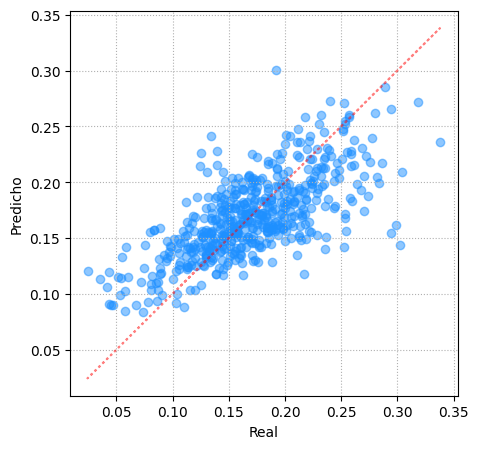

In [37]:
# Generar predicciones 
y_pred_reg = mod_reg.predict(X_test)

# Calcular R2
r2 = metrics.r2_score(y_test, y_pred_reg)
print(f"R2: {r2:.1%}")

# Contrastar valores reales vs predichos
plt.figure(figsize = [5,5])
plt.scatter(
    x = y_test,
    y = y_pred_reg,
    alpha = 0.5,
    color = "dodgerblue"
)
plt.xlabel("Real")
plt.ylabel("Predicho")
plt.plot(y_test, y_test, color = "red", alpha = 0.5, linestyle = ":")
plt.grid(linestyle = ":")
plt.show()

En vista que estamos trabajando con **Series temporales**, contrasta los valores predichos con los reales mediante una gráfica de evolución a través del tiempo.

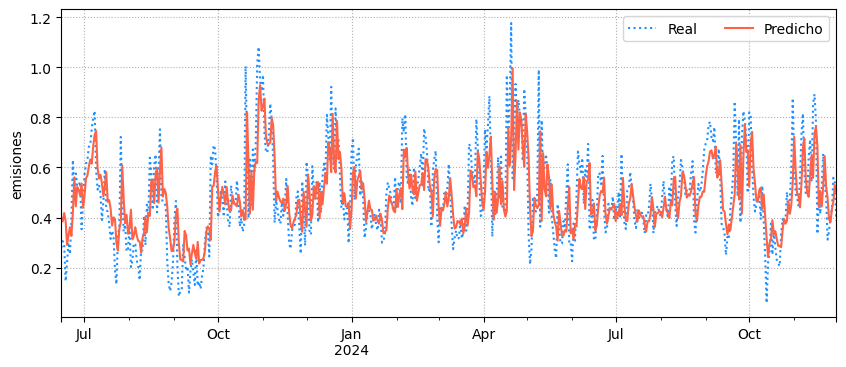

In [38]:
# Crear dataframe con valores reales y pornosticados
evolucion = pd.DataFrame(
    dict(
        Real = 10**y_test - 1,
        Predicho = 10**y_pred_reg - 1
    ),
    index = y_test.index
)

# visualizar evolución
evolucion.plot(
    figsize = [10,4],
    color = ["dodgerblue","tomato"],
    style = [":","-"],
    xlabel = "",
    ylabel = "emisiones"
)
plt.legend(ncols = 2)
plt.grid(linestyle = ":")
plt.show()

Repitamos el procedimiento de creación y evaluación pero ahora utilizando el algoritmo de **Bosque Aleatorio para Regresión**. Dado que es un ensamblaje de árboles de decisión, puedes utilizar como hiperparámetros la cantidad de algoritmos base y la profundidad de ellos, mediante argumentos `n_estimatorios = 1000` y `max_depth = 4`. Adicionalmente guarda las predicciones en la variable `y_pred_bar`. 

In [39]:
# Crear modelo
mod_bar = RandomForestRegressor(
    n_estimators = 1000,
    max_depth = 4,
    random_state = 123
)

# Entrenar modelo
mod_bar.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",1000
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

R2: 49.3%


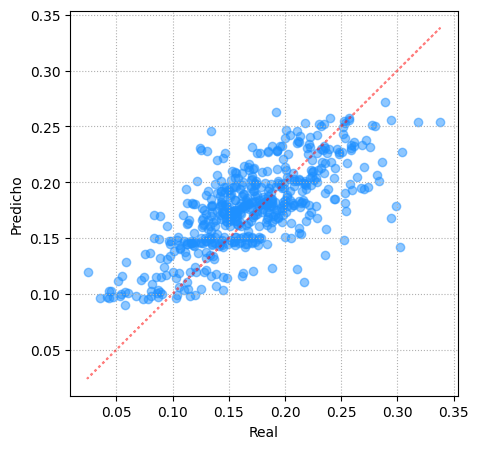

In [40]:
# Generar predicciones 
y_pred_bar = mod_bar.predict(X_test)

# Calcular R2
r2 = metrics.r2_score(y_test, y_pred_bar)
print(f"R2: {r2:.1%}")

# Contrastar valores reales vs predichos
plt.figure(figsize = [5,5])
plt.scatter(
    x = y_test,
    y = y_pred_bar,
    alpha = 0.5,
    color = "dodgerblue"
)
plt.xlabel("Real")
plt.ylabel("Predicho")
plt.plot(y_test, y_test, color = "red", alpha = 0.5, linestyle = ":")
plt.grid(linestyle = ":")
plt.show()

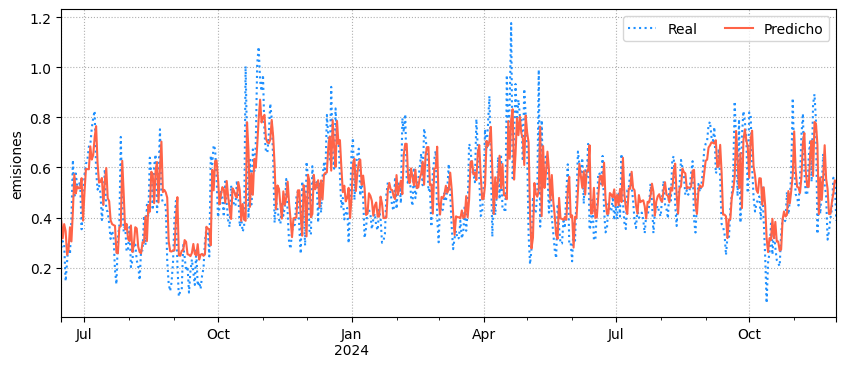

In [41]:
# Crear dataframe con valores reales y pornosticados
evolucion = pd.DataFrame(
    dict(
        Real = 10**y_test - 1,
        Predicho = 10**y_pred_bar - 1
    ),
    index = y_test.index
)

# visualizar evolución
evolucion.plot(
    figsize = [10,4],
    color = ["dodgerblue","tomato"],
    style = [":","-"],
    xlabel = "",
    ylabel = "emisiones"
)
plt.legend(ncols = 2)
plt.grid(linestyle = ":")
plt.show()

## Optimización de modelos

A continuación vamos a aprender una manera sencilla con la que podemos en algunas circunstancias optimizar modelos base y que parte de la idea del **ensamblaje** ya conocida. Piensa en cada modelo creado y entrenado como que fuera un experto, y por tanto tienes dos especialistas en emisiones que te dan sus pronósticos a modo de opoinión. Para no descartarlas, lo lógico sería combinarlas y a partir de aquí obtener un criterio más generalizado. Hagamos entonces esto definiendo una nueva variable `y_pred` que promedie las predicciones de los modelos anteriores. 

In [42]:
y_pred =  (y_pred_reg + y_pred_bar) / 2

Evalúa ahora el rendimiento de este resultado.

R2: 50.2%


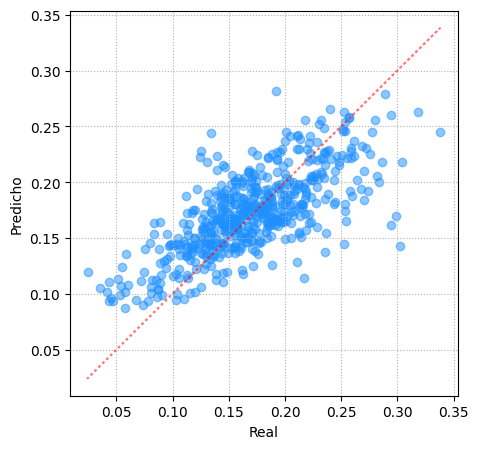

In [43]:
r2 = metrics.r2_score(y_test, y_pred)
print(f"R2: {r2:.1%}")

# Contrastar valores reales vs predichos
plt.figure(figsize = [5,5])
plt.scatter(
    x = y_test,
    y = y_pred,
    alpha = 0.5,
    color = "dodgerblue"
)
plt.xlabel("Real")
plt.ylabel("Predicho")
plt.plot(y_test, y_test, color = "red", alpha = 0.5, linestyle = ":")
plt.grid(linestyle = ":")
plt.show()

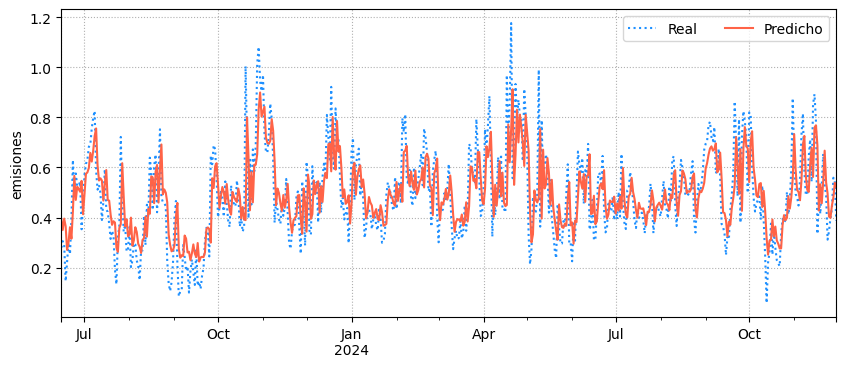

In [44]:
# Crear dataframe con valores reales y pornosticados
evolucion = pd.DataFrame(
    dict(
        Real = 10**y_test - 1,
        Predicho = 10**y_pred - 1
    ),
    index = y_test.index
)

# visualizar evolución
evolucion.plot(
    figsize = [10,4],
    color = ["dodgerblue","tomato"],
    style = [":","-"],
    xlabel = "",
    ylabel = "emisiones"
)
plt.legend(ncols = 2)
plt.grid(linestyle = ":")
plt.show()

Una mejora pequeña pero igualmente importante sin duda. Hemos creado y optimizado un modelo que es capaz de pronosticar las emisiones en la ciudad y ahora el municipio cuenta con una herramienta que le permite anticiparse al nivel de contaminacion por CO para tomar decisiones de política pública en beneficio de los habitantes de la urbe.

## Implementación del modelo

Para finalizar, en el siguiente código podrás ver cómo utilizar tu modelo para predecir las emisiones de CO de una semana en el futuro. Intenta mirar y comprender lo que hace.

```py
# Copiar el dataset original
df_pronostico = df_emisiones_d["emisiones"].copy()

# Generar pronósticos para la siguiente semana
for _ in range(7):

    # Extraer tendencia y estacionalidad
    descomp = seasonal_decompose(
        df_pronostico, 
        model = "multiplicative",
        period = 365,
        two_sided = False
    )

    # Crear nuevos atributos
    nuevos_atrib = pd.DataFrame(dict(
        tendencia = descomp.trend.iloc[-1],
        estacionalidad = descomp.seasonal.iloc[-1],
        lag_1 = df_pronostico.iloc[-1],
        lag_2 = df_pronostico.iloc[-2],
        lag_3 = df_pronostico.iloc[-3],
        lag_4 = df_pronostico.iloc[-4],
        lag_5 = df_pronostico.iloc[-5],
        lag_6 = df_pronostico.iloc[-6],
        lag_7 = df_pronostico.iloc[-7]
    ), index = [max(df_pronostico.index) + dt.timedelta(1)])

    # Generar prediccion con modelo creado y optimizado
    y_pred_reg = mod_reg.predict(nuevos_atrib)
    y_pred_bar = mod_bar.predict(nuevos_atrib)
    y_pred = (y_pred_reg + y_pred_bar) / 2

    # Incorporar resultado en observaciones historicas
    df_aux = pd.Series(10**y_pred[0] - 1, index = [max(df_pronostico.index) + dt.timedelta(1)])

    df_pronostico = pd.concat(
        [df_pronostico, df_aux]
    )

# Visualizar pronostico realizado
plt.figure(figsize = [10,4])
plt.plot(df_pronostico[-14:-7], color = "dodgerblue", marker = ".", linestyle = "--")
plt.plot(df_pronostico[-8:], color = "tomato", marker = ".")
plt.ylabel("emisiones")
plt.grid(linestyle = ":")
plt.show()
```

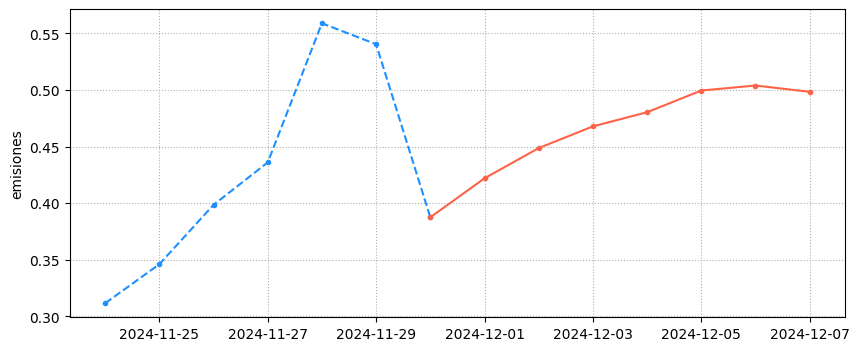

In [45]:
# Copiar el dataset original
df_pronostico = df_emisiones_d["emisiones"].copy()

# Generar pronósticos para la siguiente semana
for _ in range(7):

    # Extraer tendencia y estacionalidad
    descomp = seasonal_decompose(
        df_pronostico, 
        model = "multiplicative",
        period = 365,
        two_sided = False
    )

    # Crear nuevos atributos
    nuevos_atrib = pd.DataFrame(dict(
        tendencia = descomp.trend.iloc[-1],
        estacionalidad = descomp.seasonal.iloc[-1],
        lag_1 = df_pronostico.iloc[-1],
        lag_2 = df_pronostico.iloc[-2],
        lag_3 = df_pronostico.iloc[-3],
        lag_4 = df_pronostico.iloc[-4],
        lag_5 = df_pronostico.iloc[-5],
        lag_6 = df_pronostico.iloc[-6],
        lag_7 = df_pronostico.iloc[-7]
    ), index = [max(df_pronostico.index) + dt.timedelta(1)])

    # Generar prediccion con modelo creado y optimizado
    y_pred_reg = mod_reg.predict(nuevos_atrib)
    y_pred_bar = mod_bar.predict(nuevos_atrib)
    y_pred = (y_pred_reg + y_pred_bar) / 2

    # Incorporar resultado en observaciones historicas
    df_aux = pd.Series(10**y_pred[0] - 1, index = [max(df_pronostico.index) + dt.timedelta(1)])

    df_pronostico = pd.concat(
        [df_pronostico, df_aux]
    )

# Visualizar pronostico realizado
plt.figure(figsize = [10,4])
plt.plot(df_pronostico[-14:-7], color = "dodgerblue", marker = ".", linestyle = "--")
plt.plot(df_pronostico[-8:], color = "tomato", marker = ".")
plt.ylabel("emisiones")
plt.grid(linestyle = ":")
plt.show()